In [2]:
import os
import torch

py_folder = "pt_folder"
max_len = 0

for filename in os.listdir(py_folder):
    if filename.endswith(".pt"):
        file_path = os.path.join(py_folder, filename)
        data = torch.load(file_path, weights_only=False)

        # Assume sequence/features are in data.x (shape [L, F])
        seq_len = data.x.shape[0]  # number of residues
        if seq_len > max_len:
            max_len = seq_len

print(f"Maximum sequence length across all files: {max_len}")

c:\Users\nicol\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Maximum sequence length across all files: 48


In [1]:
import torch

# Path to your .pt file
pt_path = "1A0Q.pt"

# Load on CPU (recommended)
data = torch.load(pt_path, map_location="cpu", weights_only=False)

print(type(data))
print(data)

c:\Users\nicol\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'torch_geometric.data.data.Data'>
Data(x=[389, 20], edge_index=[2, 24844], edge_attr=[24844, 64], pos=[389, 3], sequence='IELTQSPSSLSASLGGKVTITCKASQDIKKYIGWYQHKPGKQPRLLIHYTSTLLPGIPSRFRGSGSGRDYSFSISNLEPEDIATYYCLQYYNLRTFGGGTKLEIKRADAAPTVSIFPPSSEQLTSGGASVVCFLNNFYSKDINVKWKIDGSERQNGVLNSWTDQDSKDSTYSMSSTLTLTKDEYERHNSYTCEATHKTSTSPIVKSFNRNEVQLQESDAELVKPGASVKISCKASGYTFTDHVIHWVKQKPEQGLEWIGYISPGNGDIKYNEKFKGKATLTADKSSSTAYMQLNSLTSEDSAVYLCKRGYYSMVTLGCLVKGYFPEPVTVTWNSGSLSSGVHTFPAVLQSDLYTLSSSVTVPSSTWPSETVTCNVAHPASSTKVDKKIE', edge_type=[24844])


In [1]:
import pickle
import torch

# Path to your pickle file
pkl_path = r"pt_folder\val\5GMU.pt"


obj = torch.load(pkl_path, map_location="cpu", weights_only=False)
print(obj)

c:\Users\nicol\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data(x=[84, 20], edge_index=[2, 2802], edge_attr=[2802, 64], pos=[84, 3], sequence='TELELLRQKADELNLQILKLINERGNVVKEIGKAKEQGVNRFDPVRERTMLNNIIENNDGPFENSTIQHIFKEIFKAGLELQEE', edge_type=[2802])


In [7]:
from glob import glob
import torch
import numpy as np

total_neg = 0
total_pos = 0
file_list = glob(r'binding_sites/train/*.npy')
print(file_list)
for file in file_list:
    bs_vector = np.load(file)
    total_neg += (bs_vector == 0).sum().item() / ((bs_vector == 1).sum().item() + (bs_vector == 0).sum().item())
    total_pos += (bs_vector == 1).sum().item() / ((bs_vector == 1).sum().item() + (bs_vector == 0).sum().item())
print(total_neg / len(file_list))
print(total_pos / len(file_list))

['binding_sites/train\\10GS.npy', 'binding_sites/train\\11GS.npy', 'binding_sites/train\\13GS.npy', 'binding_sites/train\\184L.npy', 'binding_sites/train\\185L.npy', 'binding_sites/train\\186L.npy', 'binding_sites/train\\187L.npy', 'binding_sites/train\\188L.npy', 'binding_sites/train\\1A07.npy', 'binding_sites/train\\1A08.npy', 'binding_sites/train\\1A09.npy', 'binding_sites/train\\1A0Q.npy', 'binding_sites/train\\1A1B.npy', 'binding_sites/train\\1A1C.npy', 'binding_sites/train\\1A1E.npy', 'binding_sites/train\\1A28.npy', 'binding_sites/train\\1A2C.npy', 'binding_sites/train\\1A30.npy', 'binding_sites/train\\1A3E.npy', 'binding_sites/train\\1A42.npy', 'binding_sites/train\\1A46.npy', 'binding_sites/train\\1A4G.npy', 'binding_sites/train\\1A4H.npy', 'binding_sites/train\\1A4M.npy', 'binding_sites/train\\1A4Q.npy', 'binding_sites/train\\1A4R.npy', 'binding_sites/train\\1A4W.npy', 'binding_sites/train\\1A52.npy', 'binding_sites/train\\1A5G.npy', 'binding_sites/train\\1A5H.npy', 'binding_

In [ ]:
from glob import glob
import torch
from tqdm import tqdm

total_neg = 0
total_pos = 0
file_list = glob(r'split_misato\train\*.pt')
my_max = 0
for file in tqdm(file_list):
    with open(file_path, "rb") as f:  # "rb" = read binary
        data = pickle.load(f)
        dmat = torch.from_numpy(data['matrix'])
        if dmat.max() > my_max:
            my_max = dmat.max().item()
print(my_max)

Data(x=[1452, 20], edge_index=[2, 187026], edge_attr=[187026, 64], pos=[1452, 3], sequence='PHSHPALTPEQKKELSDIAHRIVAPGKGILAADESTGSIAKRLQSIGTENTEENRRFYRQLLLTADDRVNPCIGGVILFHETLYQKADDGRPFPQVIKSKGGVVGIKVDKGVVPLAGTNGETTTQGLDGLSERCAQYKKDGADFAKWRCVLKIGEHTPSALAIMENANVLARYASICQQNGIVPIVEPEILPDGDHDLKRCQYVTEKVLAAVYKALSDHHIYLEGTLLKPNMVTPGHACTQKYSHEEIAMATVTALRRTVPPAVTGVTFLSGGQSEEEASINLNAINKCPLLKPWALTFSYGRALQASALKAWGGKKENLKAAQEEYVKRALANSLACQGKYTSSGQAGAAASESLFISNHAYPHSHPALTPEQKKELSDIAHRIVAPGKGILAADESTGSIAKRLQSIGTENTEENRRFYRQLLLTADDRVNPCIGGVILFHETLYQKADDGRPFPQVIKSKGGVVGIKVDKGVVPLAGTNGETTTQGLDGLSERCAQYKKDGADFAKWRCVLKIGEHTPSALAIMENANVLARYASICQQNGIVPIVEPEILPDGDHDLKRCQYVTEKVLAAVYKALSDHHIYLEGTLLKPNMVTPGHACTQKYSHEEIAMATVTALRRTVPPAVTGVTFLSGGQSEEEASINLNAINKCPLLKPWALTFSYGRALQASALKAWGGKKENLKAAQEEYVKRALANSLACQGKYTSSGQAGAAASESLFISNHAYPHSHPALTPEQKKELSDIAHRIVAPGKGILAADESTGSIAKRLQSIGTENTEENRRFYRQLLLTADDRVNPCIGGVILFHETLYQKADDGRPFPQVIKSKGGVVGIKVDKGVVPLAGTNGETTTQGLDGLSERCAQYKKDGADFAKWRCVLKIGEHTPSALAIMENANVLARYASICQQNGI

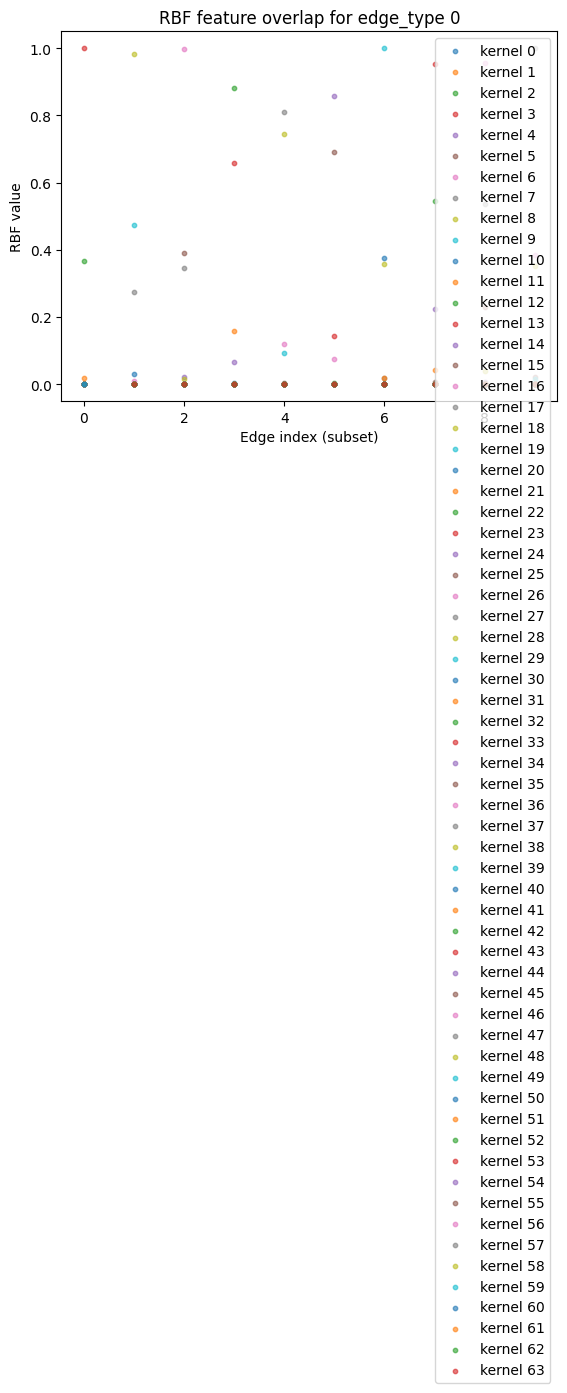

In [27]:
import torch
import matplotlib.pyplot as plt

# --- Parameters ---
pt_path = r"temp_dummy_right\1ADO.pt"  # path to your .pt file
edge_type_to_plot = 0    # which edge_type to visualize

# --- Load the Data object ---
data = torch.load(pt_path, map_location="cpu", weights_only=False)
print(data)  # quick summary

# --- Select edges with edge_type == 0 ---
mask = (data.edge_type == edge_type_to_plot)
print(f"Number of edges with edge_type {edge_type_to_plot}: {mask.sum().item()}")

# --- Extract RBF features ---
rbf_edges = data.edge_attr[mask]  # shape [num_edges, 64]

# --- Optional: choose a subset of edges to plot if too many ---
num_to_plot = min(10, rbf_edges.shape[0])
rbf_edges = rbf_edges[:num_to_plot]

num_edges, num_kernels = rbf_edges.shape

print(rbf_edges[0, :].numpy())

# --- Visualize overlap ---
for k in range(num_kernels):  # plot only first 5 kernels for clarity
    plt.scatter(
        range(num_edges),              # x-axis: edge index
        rbf_edges[:, k].numpy(),       # y-axis: RBF values
        s=10,                          # marker size
        alpha=0.6,                     # transparency
        label=f"kernel {k}"
    )

plt.xlabel("Edge index (subset)")
plt.ylabel("RBF value")
plt.title(f"RBF feature overlap for edge_type {edge_type_to_plot}")
plt.legend(loc="upper right")
plt.show()


In [2]:
import torch

pt_file = r"pt_folder_distances\train\1A0Q.pt"

data = torch.load(pt_file, map_location="cpu", weights_only=False)

print(type(data))
print(data)


<class 'torch_geometric.data.data.Data'>
Data(x=[389, 20], edge_index=[2, 6575], edge_attr=[6575, 1], pos=[389, 3], sequence='IELTQSPSSLSASLGGKVTITCKASQDIKKYIGWYQHKPGKQPRLLIHYTSTLLPGIPSRFRGSGSGRDYSFSISNLEPEDIATYYCLQYYNLRTFGGGTKLEIKRADAAPTVSIFPPSSEQLTSGGASVVCFLNNFYSKDINVKWKIDGSERQNGVLNSWTDQDSKDSTYSMSSTLTLTKDEYERHNSYTCEATHKTSTSPIVKSFNRNEVQLQESDAELVKPGASVKISCKASGYTFTDHVIHWVKQKPEQGLEWIGYISPGNGDIKYNEKFKGKATLTADKSSSTAYMQLNSLTSEDSAVYLCKRGYYSMVTLGCLVKGYFPEPVTVTWNSGSLSSGVHTFPAVLQSDLYTLSSSVTVPSSTWPSETVTCNVAHPASSTKVDKKIE', edge_type=[6575])
